# Interactive Fitter

In [9]:
%run ../../../setup_workspace.py # ../ means level up 

# Functions

In [10]:
def gaussian(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

def voigt(x, A, x0, sigma, gamma):
    return A * voigt_profile(x - x0, sigma, gamma) / voigt_profile(0, sigma, gamma)



def linear(x, k, b):
    return k * x + b
    
def linear_2points(x, x1, y1, x2, y2):
    k = (y2 - y1) / (x2 - x1)
    b = y1 - k * x1

    return linear(x, k, b)

In [11]:
func_lib = {
    'gaussian': gaussian,
    'voigt': voigt,
}

# Analysis

Found 103 EDF files in SAXS


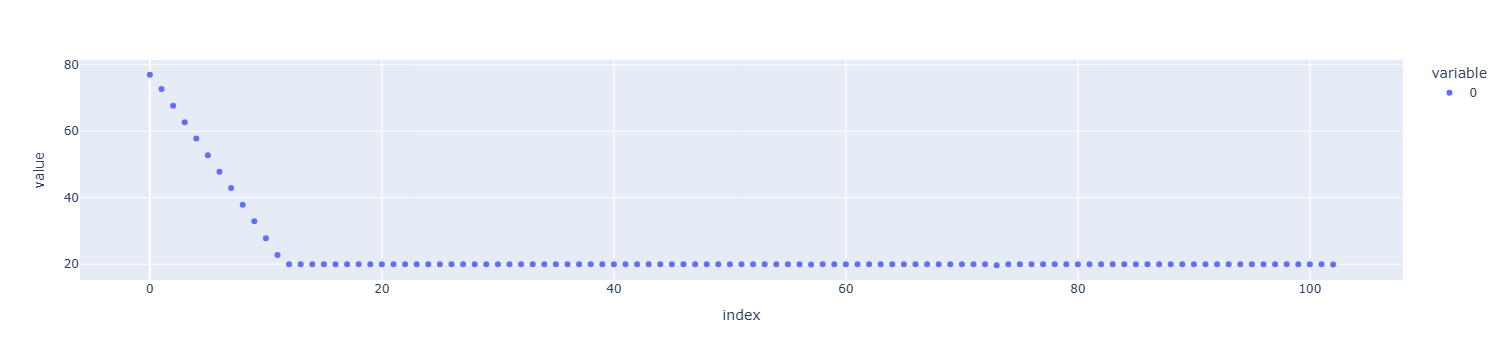

<Figure size 500x500 with 0 Axes>

In [81]:
path = r'E:/PEG_PCL/March_2025/Water/Bottlebrush_PCL_PEG_PCL_PEG_20perc_20C_cryst_bis'

Exp = BM26_experiment(path)
plt.figure(figsize=(5,5))
px.scatter(Exp.get_T_profile())

### SAXS

(0.2, 4)

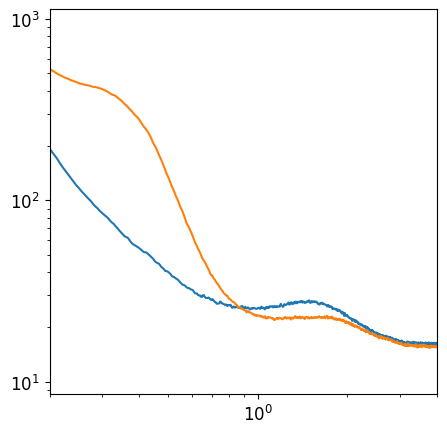

In [22]:
start = 24
end = 82

plt.figure(figsize=(5,5))
q, I = Exp.get_1d_SAXS(start)
plt.plot(q, I)

q, I = Exp.get_1d_SAXS(end)
plt.plot(q, I)


plt.semilogx()
plt.semilogy()

plt.xlim(0.2, 4)

### WAXS

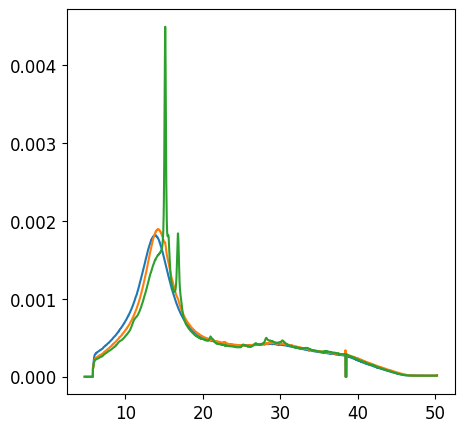

In [62]:
start = 24
end = 82

plt.figure(figsize=(5,5))
q_amorph, I_amorph = Exp.get_1d_WAXS(19)
plt.plot(q_amorph, I_amorph)

q, I = Exp.get_1d_WAXS(start)
plt.plot(q, I)

q, I = Exp.get_1d_WAXS(end)
plt.plot(q, I)

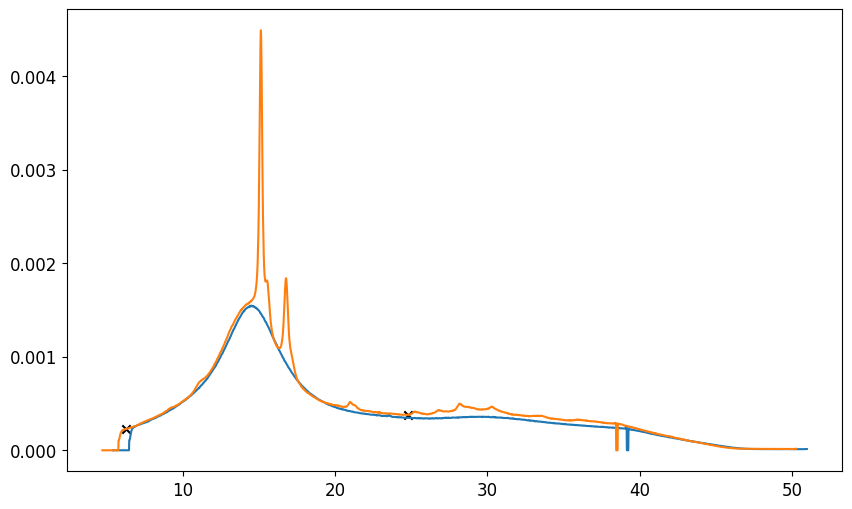

In [78]:
plt.plot(q_amorph + 0.7, 0.85 * I_amorph)

q, I = Exp.get_1d_WAXS(end)

plt.plot(q, I)

l = 100
r = 1300

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.99

# plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

In [60]:
X = x
Y = 
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

SyntaxError: invalid syntax (1176485290.py, line 2)

In [41]:
def Voigt_C(x, a, x0, sigma, gamma, C):
    return voigt(x, a, x0, sigma, gamma) + C